#Section 1 — Problem Statement
# Customer Churn Prediction using ML Pipeline

## Objective
The goal of this project is to build a reusable and production-ready machine learning pipeline to predict customer churn in a telecom company.

Customer churn occurs when a customer stops using the company's service. Predicting churn helps companies take proactive measures to retain customers.

## Dataset
Telco Customer Churn Dataset

The dataset contains customer information such as:
- Gender
- Tenure
- Contract type
- Monthly charges
- Internet service

Target Variable:
Churn (Yes / No)

#Section 2 — Import Libraries

In [ ]:
!pip install pandas scikit-learn joblib

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

import joblib

#Section 3 — Load Dataset

In [ ]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#Section 4 — Dataset Exploration

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


#Section 5 — Target Variable Analysis

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


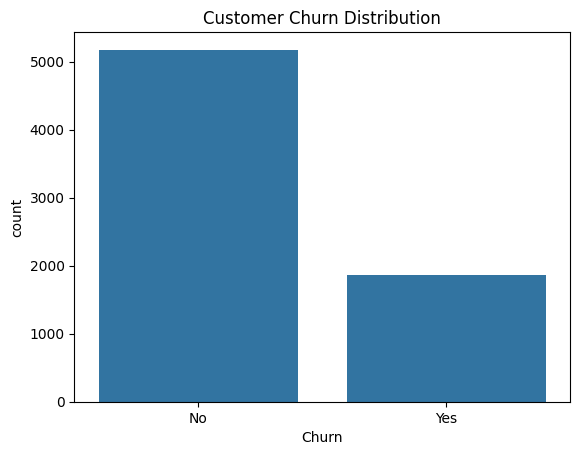

In [ ]:
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

#Section 6 — Data Preprocessing

In [ ]:
df.drop('customerID', axis=1, inplace=True)

In [ ]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

#Section 7 — Train Test Split

In [ ]:
X = df.drop('Churn', axis=1)

y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#Section 8 — Identify Column Types

In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns

numerical_cols = X.select_dtypes(exclude=['object']).columns

In [ ]:
print("Categorical:", categorical_cols)

print("Numerical:", numerical_cols)

Categorical: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object')
Numerical: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


#Section 9 — Preprocessing Pipelines

Numerical Pipeline

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

Categorical Pipeline

In [ ]:
categorical_transformer = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

#Section 10 — Column Transformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

#Section 11 — Logistic Regression Pipeline

In [ ]:
pipeline_lr = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]
)

#Section 12 — Logistic Regression Hyperparameter Tuning

Define Parameter Grid

In [ ]:
param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}

Apply GridSearchCV

In [ ]:
grid_search_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=5,
    scoring='accuracy'
)

Train GridSearch Model

In [ ]:
grid_search_lr.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'Multipl...
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__penalty': ['l2'], 'model__solver': ['lbfgs']},
             scoring='accuracy')

Best Parameters

In [ ]:
grid_search_lr.best_params_

{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Evaluate Tuned Logistic Regression Model

In [ ]:
best_lr_model = grid_search_lr.best_estimator_

y_pred_lr = best_lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8239886444286728
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.70      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



#Section 13 — Random Forest Pipeline

In [ ]:
pipeline_rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier())
    ]
)

In [ ]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None]
}
grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=5,
    scoring='accuracy'
)

Train

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                                       ('model', RandomForestClassifier())]),
             param_grid={'model__max_depth': [5, 10, None],
                         'model__n_estimators': [100, 200]},
             scoring='accuracy')

In [ ]:
grid_search.best_params_

{'model__max_depth': None, 'model__n_estimators': 200}

#Section 15 — Random Forest Best Model Evaluation

In [ ]:
best_model = grid_search.best_estimator_


In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7927608232789212


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.65      0.47      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



#Section 16 — Logistic Regression Best Model Evaluation

In [ ]:
best_lr_model = grid_search_lr.best_estimator_

y_pred_lr = best_lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8239886444286728
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.70      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



#Section 17 — Model Comparison

In [ ]:
rf_accuracy = accuracy_score(y_test, best_model.predict(X_test))

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.823989
1,Random Forest,0.792761


#Section 18 — Select Best Model

In [ ]:
if rf_accuracy > lr_accuracy:

    final_model = best_model
    print("Random Forest Selected as Final Model")

else:

    final_model = best_lr_model
    print("Logistic Regression Selected as Final Model")

Logistic Regression Selected as Final Model


#Section 19 — Export Final Model

In [ ]:
joblib.dump(final_model, "churn_pipeline.pkl")

['churn_pipeline.pkl']

## Final Conclusion

In this project, we developed an end-to-end machine learning pipeline to predict customer churn for a telecom company. The objective was to build a reusable and production-ready workflow using Scikit-learn’s Pipeline API.

The dataset was first explored and preprocessed by handling categorical and numerical features separately. Categorical variables were encoded using OneHotEncoder while numerical features were scaled using StandardScaler. These preprocessing steps were combined using a ColumnTransformer to ensure consistent transformations during both training and prediction.

Two machine learning models were implemented in this pipeline:
- Logistic Regression
- Random Forest Classifier

Hyperparameter tuning was performed for both models using GridSearchCV to identify the best performing configurations. The tuned models were then evaluated on the test dataset using accuracy and classification metrics.

After evaluation, both models were compared based on their performance. The model with the higher accuracy was selected as the final model for deployment.

Finally, the complete machine learning pipeline, including preprocessing steps and the trained model, was exported using Joblib. This allows the pipeline to be easily reused in production systems without repeating the preprocessing and training steps.

This project demonstrates how to build a scalable and production-ready machine learning workflow using Scikit-learn pipelines and model optimization techniques.